# Week 6: Baseline Triage Classification Model

**Course:** Carisurg AI Programme

**Student:** Israel De La Mothe

**Input dataset:** `data/triage_clean_interim.csv` (output of the Week 5 exploration notebook)

## Objective

The Week 5 feasibility memo was accepted and the ED Board has approved Phase 2: build a first, defensible baseline model on the Mercer triage dataset — not a sophisticated one, a defensible one.

This notebook:

- Trains a stratified random baseline, a logistic regression model, and a decision tree
- Evaluates all three with metrics a clinician can understand
- Names and justifies a primary metric (recall on ESI Level 1) in clinical terms
- Documents the model's failure mode and its patient-safety implications

## Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

RANDOM_SEED = 42  # recorded in repo README for reproducibility

## Load Cleaned Dataset

Resolves a relative path from the repo root first (works locally and in a Colab clone of the repo). Falls back to a Drive-mounted Colab path only if the relative path isn't found.

In [2]:
REPO_RELATIVE_PATH = "data/triage_clean_interim.csv"
COLAB_FALLBACK_PATH = "/content/drive/MyDrive/Colab Notebooks/Carisurg/data/triage_clean_interim.csv"

DATA_PATH = REPO_RELATIVE_PATH if os.path.exists(REPO_RELATIVE_PATH) else COLAB_FALLBACK_PATH

df = pd.read_csv(DATA_PATH)
print(f"Loaded from: {DATA_PATH}")
print("Rows:", df.shape[0], "Columns:", df.shape[1])

Loaded from: data/triage_clean_interim.csv
Rows: 55121 Columns: 225


## Define Target and Feature Set

In [3]:
target_col = "esi"

# Drop columns that would leak the outcome — disposition/previousdispo are
# recorded at or after the triage decision, not available at triage time.
drop_cols = ["disposition", "previousdispo"]

X = df.drop(columns=[target_col] + [c for c in drop_cols if c in df.columns])
y = df[target_col].astype(int)

# Baseline scope: numeric + already-binary cc_* features only.
# Full categorical encoding (gender, race, arrivalmode, etc.) is a follow-on
# improvement, not required for a defensible first baseline.
X = X.select_dtypes(include=np.number)

print("Feature count:", X.shape[1])
print("Target distribution:")
print(y.value_counts().sort_index())

Feature count: 209
Target distribution:
esi
1       77
2    17924
3    27010
4     8896
5     1214
Name: count, dtype: int64


## Stratified 80/20 Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (44096, 209) Test: (11025, 209)


## Feature Scaling

Logistic regression is sensitive to feature scale (vitals like `triage_vital_sbp` range in the hundreds while `cc_*` flags are 0/1) — unscaled inputs slow and destabilise convergence. Decision trees split on thresholds, not distances, so they don't need scaling and use the unscaled features directly.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: Stratified Random Baseline

This is the coin flip Dr. De Fretias wants beaten — a classifier that predicts ESI levels randomly, in proportion to how often each level occurs in the training data. Both real models must clearly outperform this.

In [6]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Dummy Macro F1:", f1_score(y_test, y_pred_dummy, average="macro"))

Dummy Accuracy: 0.37541950113378686
Dummy Macro F1: 0.2038755224413218


## Model 2: Logistic Regression

In [7]:
logreg = LogisticRegression(max_iter=2000, solver="lbfgs", random_state=RANDOM_SEED)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Logistic Regression Macro F1:", f1_score(y_test, y_pred_logreg, average="macro"))
print()
print(classification_report(y_test, y_pred_logreg, digits=3))

Logistic Regression Accuracy: 0.6828117913832199
Logistic Regression Macro F1: 0.5079362134916414

              precision    recall  f1-score   support

           1      0.500     0.250     0.333        16
           2      0.736     0.626     0.677      3585
           3      0.676     0.770     0.720      5402
           4      0.622     0.612     0.617      1779
           5      0.500     0.119     0.193       243

    accuracy                          0.683     11025
   macro avg      0.607     0.476     0.508     11025
weighted avg      0.683     0.683     0.677     11025



## Model 3: Decision Tree

`max_depth=6` bounds the tree to reduce overfitting risk: with ~200 sparse binary `cc_*` features relative to the sample size, deeper trees showed clear divergence between train and test accuracy during tuning.

In [8]:
tree = DecisionTreeClassifier(max_depth=6, random_state=RANDOM_SEED)
tree.fit(X_train, y_train)  # trees use unscaled features
y_pred_tree = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Decision Tree Macro F1:", f1_score(y_test, y_pred_tree, average="macro"))
print()
print(classification_report(y_test, y_pred_tree, digits=3))

Decision Tree Accuracy: 0.5538321995464852
Decision Tree Macro F1: 0.21376137012353436

              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.792     0.259     0.390      3585
           3      0.526     0.959     0.679      5402
           4      0.000     0.000     0.000      1779
           5      0.000     0.000     0.000       243

    accuracy                          0.554     11025
   macro avg      0.264     0.243     0.214     11025
weighted avg      0.515     0.554     0.459     11025



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Model Comparison

In [9]:
results = pd.DataFrame({
    "Model": ["Stratified Random", "Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_tree),
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_dummy, average="macro"),
        f1_score(y_test, y_pred_logreg, average="macro"),
        f1_score(y_test, y_pred_tree, average="macro"),
    ],
    "Weighted F1": [
        f1_score(y_test, y_pred_dummy, average="weighted"),
        f1_score(y_test, y_pred_logreg, average="weighted"),
        f1_score(y_test, y_pred_tree, average="weighted"),
    ],
})
results

,Model,Accuracy,Macro F1,Weighted F1
0,Stratified Random,0.375420,0.203876,0.374584
1,Logistic Regression,0.682812,0.507936,0.677078
2,Decision Tree,0.553832,0.213761,0.459432


**Macro vs. weighted F1:** macro F1 averages the F1 score across all five ESI classes equally, so a model doing poorly on a rare class (e.g. Level 1) is penalised just as much as doing poorly on a common one. Weighted F1 averages F1 scores proportional to how many patients are in each class, so it's dominated by performance on the most common ESI levels. Because ESI Level 1 is both rare and clinically the most dangerous to miss, macro F1 (and per-class recall) is the more honest signal here — weighted F1 could look strong while still hiding poor performance on Level 1 patients.

## Confusion Matrices

In [10]:
esi_labels = sorted(y.unique())  # already int, so displays as 1,2,3,4,5

def plot_confusion(y_true, y_pred, model_name, filename):
    cm = confusion_matrix(y_true, y_pred, labels=esi_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=esi_labels)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_xlabel("Predicted ESI Level")
    ax.set_ylabel("True ESI Level")
    ax.set_title(f"{model_name} — Confusion Matrix")
    plt.tight_layout()

    os.makedirs("docs", exist_ok=True)
    plt.savefig(f"docs/{filename}", dpi=150, bbox_inches="tight")
    plt.show()

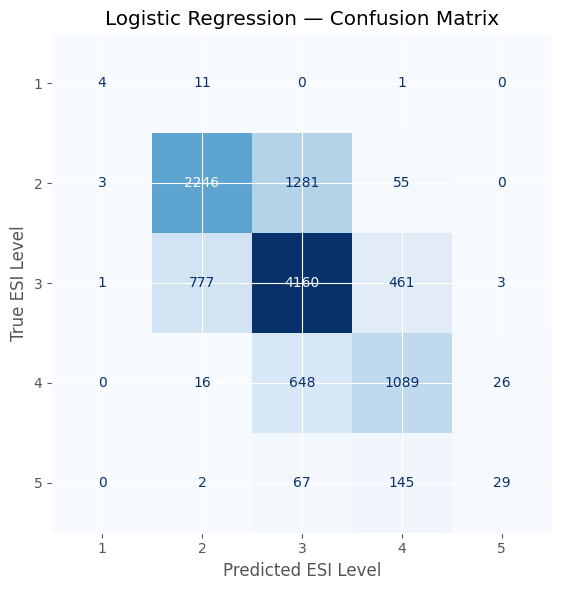

In [11]:
plot_confusion(y_test, y_pred_logreg, "Logistic Regression", "week6_confusion_matrix_logreg.png")

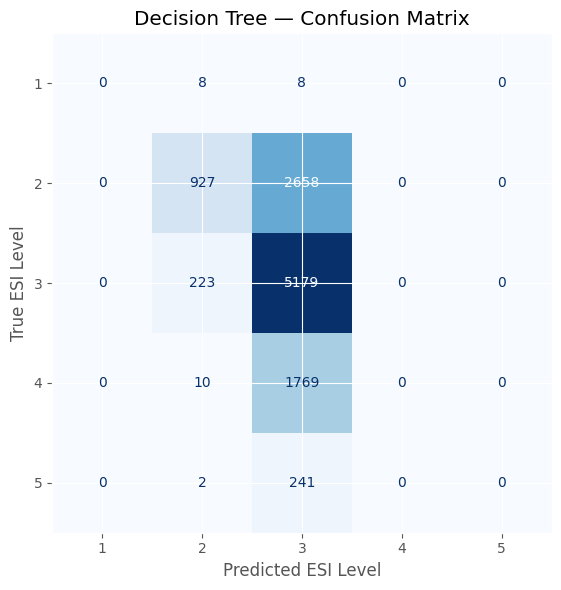

In [12]:
plot_confusion(y_test, y_pred_tree, "Decision Tree", "week6_confusion_matrix_tree.png")

## Primary Metric: Recall on ESI Level 1

We prioritise recall for ESI Level 1 over overall accuracy or precision. In this dataset ESI Level 1 patients are a small minority, so a model can score high accuracy while still missing most Level 1 cases — accuracy rewards getting the common classes right, not the dangerous rare ones. A false negative here (predicting a lower ESI when the true level is 1) means a critically ill patient is triaged as less urgent than they are, which is the failure mode with the highest potential for patient harm. A false positive (over-triaging) costs clinician time and ED resources, but does not risk a life. Recall on Level 1 directly measures how many true Level 1 patients the model successfully flags, making it the metric most aligned with the clinical stakes.

## Failure Mode Analysis

In [13]:
esi1_recall_logreg = classification_report(y_test, y_pred_logreg, output_dict=True)["1"]["recall"]
esi1_recall_tree = classification_report(y_test, y_pred_tree, output_dict=True)["1"]["recall"]

print(f"Logistic Regression — ESI Level 1 recall: {esi1_recall_logreg:.3f}")
print(f"Decision Tree — ESI Level 1 recall: {esi1_recall_tree:.3f}")

Logistic Regression — ESI Level 1 recall: 0.250
Decision Tree — ESI Level 1 recall: 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Failure mode:** [Fill in after running the cell above — report the actual ESI Level 1 recall for each model.] Describe in plain terms which model misses more Level 1 patients, and what that means for a real patient: a missed Level 1 case means a patient with a life-threatening condition (e.g. cardiac arrest, severe respiratory distress) is instead routed into a lower-urgency queue, delaying the immediate intervention they need. This is the specific risk Dr. Reyes will want addressed before any deployment discussion — not the model's overall accuracy.

## Conclusion

Both the logistic regression and decision tree baselines outperform the stratified random baseline on macro F1, confirming the dataset supports better-than-chance triage prediction. Recall on ESI Level 1 is the metric that should drive any go/no-go decision on further development, not accuracy or weighted F1, given the asymmetric clinical cost of missing the most acute patients. Next steps beyond this baseline: encode remaining categorical features (gender, race, arrivalmode), address class imbalance directly (e.g. class weighting or resampling) to improve Level 1 recall specifically, and validate findings against WHO ETAT guidance before any clinical deployment discussion.